# Exercise 2: k-means of human urbanization

/Users/luischan/miniconda3/lib/python3.11/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


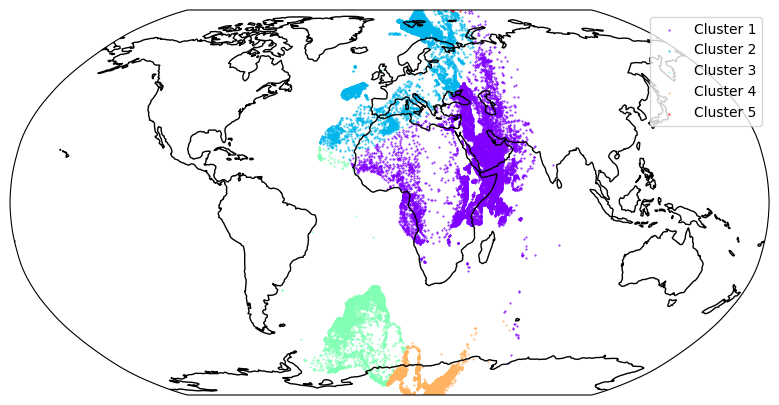

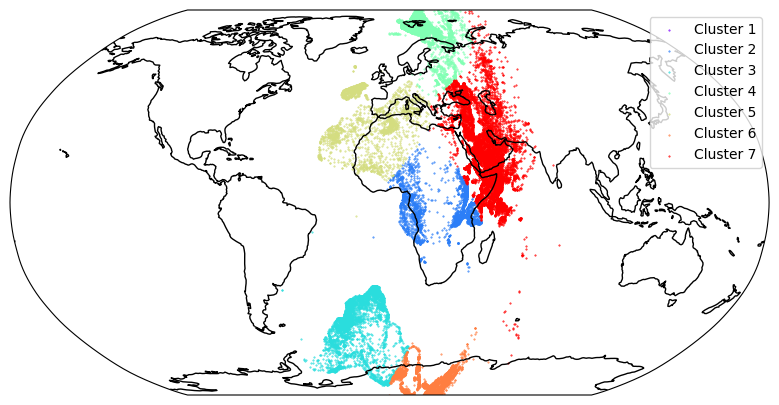

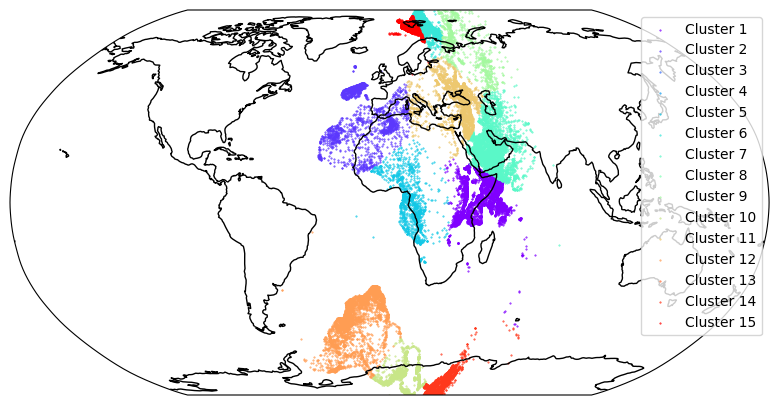

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import random

# Load the city coordinates data
data = pd.read_csv('/Users/luischan/Downloads/simplemaps_worldcities_basicv1/worldcities.csv')
latitudes = data['lat']
longitudes = data['lng']

# Convert lat/lon to Cartesian coordinates
def lat_lon_to_cartesian(lat, lon):
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)
    x = np.cos(lat_rad) * np.cos(lon_rad)
    y = np.cos(lat_rad) * np.sin(lon_rad)
    z = np.sin(lat_rad)
    return np.array([x, y, z])

def cartesian_to_lat_lon(cartesian_coords):
    x, y, z = cartesian_coords
    lon = np.arctan2(y, x)
    hyp = np.sqrt(x**2 + y**2)
    lat = np.arctan2(z, hyp)
    return np.degrees(lat), np.degrees(lon)

def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

# Convert all points to Cartesian coordinates
points = np.array([lat_lon_to_cartesian(lat, lon) for lat, lon in zip(latitudes, longitudes)])

# Implement k-means with cosine similarity
def k_means_spherical(points, k, max_iters=100):
    # Randomly initialize k centroids
    centroids = random.sample(list(points), k)
    for iteration in range(max_iters):
        # Assign points to the closest centroid based on cosine similarity
        clusters = [[] for _ in range(k)]
        for point in points:
            similarities = [cosine_similarity(point, centroid) for centroid in centroids]
            closest_centroid_idx = np.argmax(similarities)
            clusters[closest_centroid_idx].append(point)

        # Update centroids
        new_centroids = []
        for cluster in clusters:
            if cluster:  # Avoid division by zero
                centroid = np.mean(cluster, axis=0)
                centroid /= np.linalg.norm(centroid)  # Normalize to unit vector
                new_centroids.append(centroid)
            else:
                # Reinitialize a random centroid if cluster is empty
                new_centroids.append(random.choice(points))
        # Check for convergence
        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids
    return clusters, centroids

# Plot the results on a map
def plot_clusters(clusters, centroids, k):
    fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': ccrs.Robinson()})
    ax.set_global()
    ax.coastlines()

    # Plot each cluster in a different color
    colors = plt.cm.rainbow(np.linspace(0, 1, k))
    for i, (cluster, color) in enumerate(zip(clusters, colors)):
        cluster_lat_lon = [cartesian_to_lat_lon(point) for point in cluster]
        lons, lats = zip(*cluster_lat_lon)
        ax.scatter(lons, lats, s=0.2, color=color, transform=ccrs.PlateCarree(), label=f"Cluster {i+1}")
    
    plt.legend()
    plt.show()

# Run k-means for different values of k and plot the results
for k in [5, 7, 15]:
    clusters, centroids = k_means_spherical(points, k)
    plot_clusters(clusters, centroids, k)


## 

# Conclusion for Exercise 2

### Acknowledgment
The dataset used in this exercise, which includes latitude and longitude information for various cities worldwide, was obtained from SimpleMaps (https://simplemaps.com/data/world-cities) under the CC BY 4.0 license.

### Overview of Methodology
To perform clustering on a spherical surface, we adapted Lloyd's algorithm for k-means clustering by modifying the distance metric. Instead of using the Euclidean distance, we converted latitude and longitude coordinates to 3D Cartesian coordinates (x, y, z) and used cosine similarity to determine cluster assignments. This approach allowed for more accurate clustering on a globe, avoiding the distortions that might occur if latitudes and longitudes were used directly.

### Visualization and Map Projection
The results were visualized on a Robinson projection map using Cartopy, which effectively preserved the geographical integrity of the clusters on a global scale. Each cluster was color-coded, making it easy to see how urban centers grouped according to the chosen value of k.

### Experimentation with Different k Values
We ran the k-means clustering algorithm for k=5, k=7, and k=15, and observed the following:

1. **For k=5**:
   - The clustering focused on broader regions, with continents like Africa, Europe, and Oceania forming distinct clusters.
   - This resulted in larger, more generalized clusters, with many countries grouped together.

2. **For k=7**:
   - Increasing k to 7 added more diversity, further splitting regions like Europe and the Middle East into separate clusters.
   - Clusters began to capture more local population centers, creating more granularity in the representation.

3. **For k=15**:
   - With k=15, clusters became highly localized, separating even smaller regions and capturing specific urban concentrations within continents.
   - This configuration highlighted dense urban areas more distinctly, providing an in-depth view of human urbanization patterns on a global scale.

### Diversity of Results
Due to the pseudorandom initialization of centroids, running the algorithm multiple times yielded slightly different results. However, the general pattern of clustering for each k value remained consistent, demonstrating the algorithm’s robustness in identifying stable clusters based on human urbanization patterns.

### Conclusion
This exercise demonstrated the utility of modifying k-means clustering to handle spherical data accurately. By converting coordinates to Cartesian form and using cosine similarity, we were able to perform meaningful clustering of cities around the globe. The choice of k significantly affected the clustering outcome, with higher values capturing finer urbanization details and lower values focusing on broader geographic regions. These insights provide valuable information about global population centers and human settlement patterns when viewed through the lens of spatial clustering.

The approach and modifications described here can be effectively applied to any geographic clustering task where the data points lie on a spherical surface, making it an adaptable solution for global-scale clustering applications.
